# Registration prior — warp visualisation (1D / 2D)

Shows, for a **single shared draw** of the true function `f` and the warp pair `(v_A, v_B)`, what changes as the relative-warp coefficient `rho` varies:

- **latent frame**: `f(z)` on `z ~ [0,1]^d` — the ground truth, undistorted.
- **A's frame**: the same `f`, but plotted against `x̃^A = Φ_0(z)` (A's own warp — fixed, independent of `rho`), with A's actual sampled (noisy) points overlaid.
- **E's frame at `rho`**: the same `f`, plotted against `x̃^E = Φ_ρ(z)` where `Φ_ρ = flow((1-ρ)·v_A + ρ·v_B)`, with E's sampled points overlaid.

At `rho=0`, `Φ_ρ ≡ Φ_0`, so **A's and E's panels should look identical** — this is the `rho=0` identity-transport invariant (CLAUDE.md: "ρ=0 ⇒ transport is exactly the identity"). As `rho → 1`, E's warp becomes an independent draw (`Φ_1 = flow(v_B)`), and its panel should diverge visibly from A's.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from ppfn.prior.registration.function_prior import sample_function_prior
from ppfn.prior.registration.normalize import normalize
from ppfn.prior.registration.region import sample_latent_A, sample_latent_B
from ppfn.prior.registration.warp import (
    declared_box,
    flow_rk4,
    mix_velocity,
    sample_warp_pair,
)

plt.rcParams["figure.dpi"] = 110

COLOR_A = "#D55E00"
COLOR_E = "#4477AA"
RHOS = [0.0, 0.5, 1.0]

# ARCHITECTURE.md §1.3's calibrated training default is s_max=0.1 (tuned for
# a low per-draw rejection rate, not visual clarity) -- severity is drawn
# ~Uniform(0,1)*s_max per field, so at 0.1 a "typical" draw barely warps at
# all when plotted. DEMO_S_MAX is deliberately larger, purely so the warp is
# visually obvious in this notebook; it plays no role in training.
S_MAX_PRODUCTION = 0.1
DEMO_S_MAX = 1.0

## 1D

In [2]:
SEED = 3  # picked for a visually clear, roughly balanced warp severity on both A and E -- see the printed severities below
D = 1
N_A = 40   # scarce, decoder cloud
N_B = 300  # abundant, encoder cloud
GRID_N_1D = 300

rng = np.random.default_rng(SEED)

# One shared draw: the SAME (v_A, v_B, f) is reused for every rho below.
# rho only changes how v_A/v_B are mixed into E's warp Phi_rho -- reusing
# the same function/warp pair is what isolates "the effect of warping"
# instead of conflating it with a fresh random function each time.
v_a, v_b = sample_warp_pair(rng, d=D, s_max=DEMO_S_MAX)
z_a, region, volume_fraction = sample_latent_A(rng, D, N_A)
z_b = sample_latent_B(rng, D, N_B)
f = sample_function_prior(rng, D, probe_z=np.concatenate([z_a, z_b], axis=0))

box_a = declared_box(v_a, D)

z_grid = np.linspace(0.0, 1.0, GRID_N_1D)[:, None]
true_y_grid = f(z_grid)  # noiseless f(z) -- the ground truth, in the shared latent frame

x_a_grid = normalize(flow_rk4(v_a, z_grid), box_a)  # A's warp Phi_0, applied to the dense grid
x_a_norm = normalize(flow_rk4(v_a, z_a), box_a)      # ... and to A's actual sampled points
y_a = f.sample_y(rng, z_a)                           # noisy observations at those points

print(f"region: {region.kind}, volume_fraction={volume_fraction:.3f}")
print(f"v_a severity={v_a.severity:.3f}, v_b severity={v_b.severity:.3f}")

region: subbox, volume_fraction=0.334
v_a severity=0.400, v_b severity=0.405


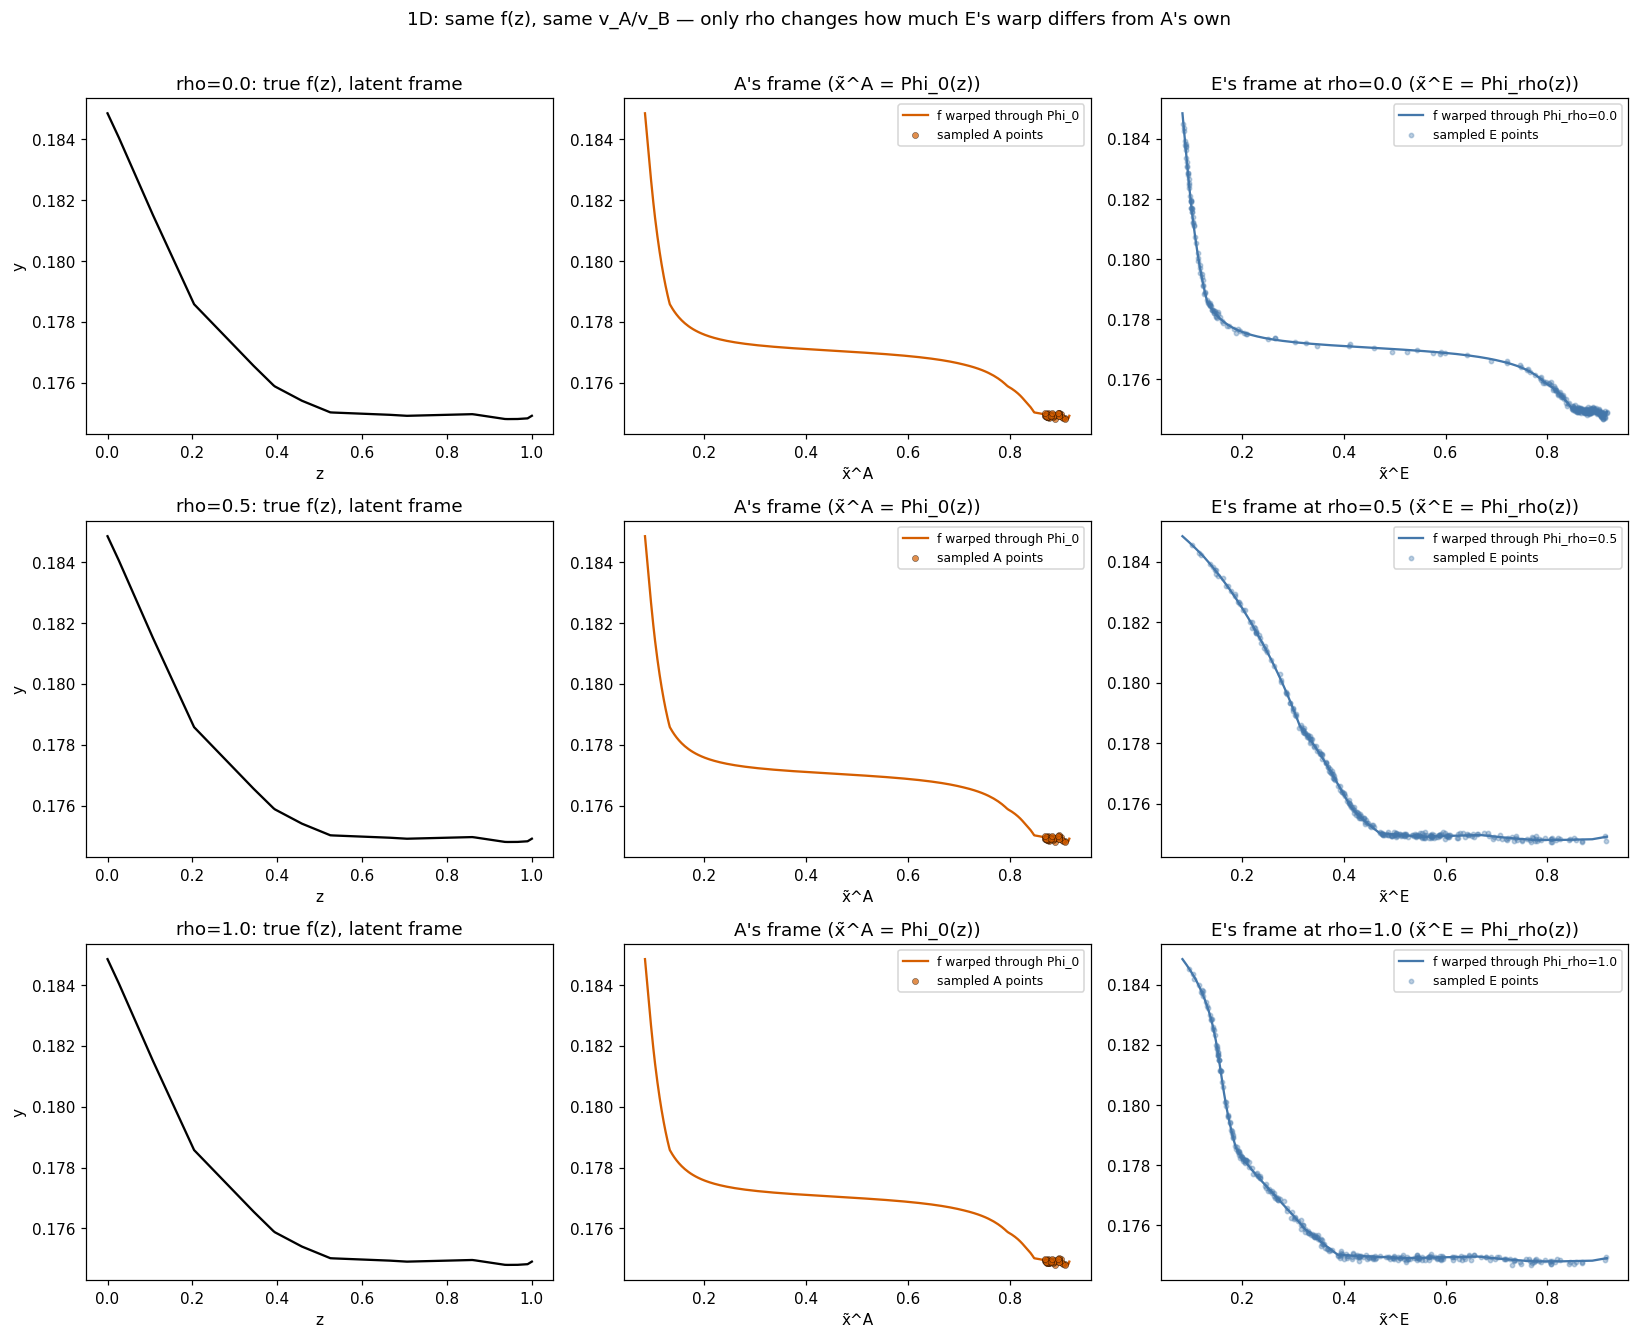

In [3]:
fig, axes = plt.subplots(len(RHOS), 3, figsize=(15, 4 * len(RHOS)), squeeze=False)

for row, rho in enumerate(RHOS):
    ax_z, ax_a, ax_e = axes[row]

    # E's warp at this rho: Phi_rho = flow of ((1-rho) v_A + rho v_B).
    # At rho=0 this is v_A exactly, so x_e_grid/x_e_norm below should
    # coincide with x_a_grid/x_a_norm -- the rho=0 identity-transport check.
    phi_rho = mix_velocity([v_a, v_b], [1.0 - rho, rho])
    box_e = declared_box(phi_rho, D)
    x_e_grid = normalize(flow_rk4(phi_rho, z_grid), box_e)
    x_e_norm = normalize(flow_rk4(phi_rho, z_b), box_e)
    y_e = f.sample_y(rng, z_b)

    ax_z.plot(z_grid[:, 0], true_y_grid, color="black", lw=1.5)
    ax_z.set_title(f"rho={rho}: true f(z), latent frame")
    ax_z.set_xlabel("z")
    ax_z.set_ylabel("y")

    ax_a.plot(x_a_grid[:, 0], true_y_grid, color=COLOR_A, lw=1.5, label="f warped through Phi_0")
    ax_a.scatter(x_a_norm[:, 0], y_a, s=16, color=COLOR_A, alpha=0.7,
                 edgecolor="black", linewidth=0.3, label="sampled A points", zorder=3)
    ax_a.set_title("A's frame (x\u0303^A = Phi_0(z))")
    ax_a.set_xlabel("x\u0303^A")
    ax_a.legend(fontsize=8, loc="best")

    ax_e.plot(x_e_grid[:, 0], true_y_grid, color=COLOR_E, lw=1.5, label=f"f warped through Phi_rho={rho}")
    ax_e.scatter(x_e_norm[:, 0], y_e, s=8, color=COLOR_E, alpha=0.35, label="sampled E points", zorder=3)
    ax_e.set_title(f"E's frame at rho={rho} (x\u0303^E = Phi_rho(z))")
    ax_e.set_xlabel("x\u0303^E")
    ax_e.legend(fontsize=8, loc="best")

fig.suptitle("1D: same f(z), same v_A/v_B — only rho changes how much E's warp differs from A's own", y=1.01)
fig.tight_layout()
plt.show()

**What to look for:** the middle (A) column is identical across rows (A's warp never depends on rho). At `rho=0` the right (E) column should look like an exact copy of the middle column — same curve shape, same x-range, points densely covering the same span. As `rho` increases the right column's curve visibly stretches/compresses differently from A's, and by `rho=1` it's an independent warp of the same underlying function.

## 2D

In [4]:
SEED_2D = 4  # picked for a visually clear, roughly balanced warp severity on both A and E
D2 = 2
N_A_2D = 60
N_B_2D = 500
GRID_N_2D = 60  # GRID_N_2D x GRID_N_2D mesh

rng2 = np.random.default_rng(SEED_2D)

v_a2, v_b2 = sample_warp_pair(rng2, d=D2, s_max=DEMO_S_MAX)
z_a2, region2, volume_fraction2 = sample_latent_A(rng2, D2, N_A_2D)
z_b2 = sample_latent_B(rng2, D2, N_B_2D)
f2 = sample_function_prior(rng2, D2, probe_z=np.concatenate([z_a2, z_b2], axis=0))

box_a2 = declared_box(v_a2, D2)

lin = np.linspace(0.0, 1.0, GRID_N_2D)
gz1, gz2 = np.meshgrid(lin, lin, indexing="ij")
z_grid2 = np.stack([gz1.ravel(), gz2.ravel()], axis=-1)  # [GRID_N_2D**2, 2]
true_y_grid2 = f2(z_grid2).reshape(GRID_N_2D, GRID_N_2D)

x_a_grid2 = normalize(flow_rk4(v_a2, z_grid2), box_a2)
x_a_norm2 = normalize(flow_rk4(v_a2, z_a2), box_a2)
y_a2 = f2.sample_y(rng2, z_a2)

print(f"region: {region2.kind}, volume_fraction={volume_fraction2:.3f}")
print(f"v_a2 severity={v_a2.severity:.3f}, v_b2 severity={v_b2.severity:.3f}")

region: subbox, volume_fraction=0.265
v_a2 severity=0.251, v_b2 severity=0.367


/tmp/ipykernel_357377/2974535232.py:24: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax_a.pcolormesh(Xa1, Xa2, true_y_grid2, cmap="viridis", vmin=vmin, vmax=vmax, shading="auto")
/tmp/ipykernel_357377/2974535232.py:32: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax_e.pcolormesh(Xe1, Xe2, true_y_grid2, cmap="viridis", vmin=vmin, vmax=vmax, shading="auto")


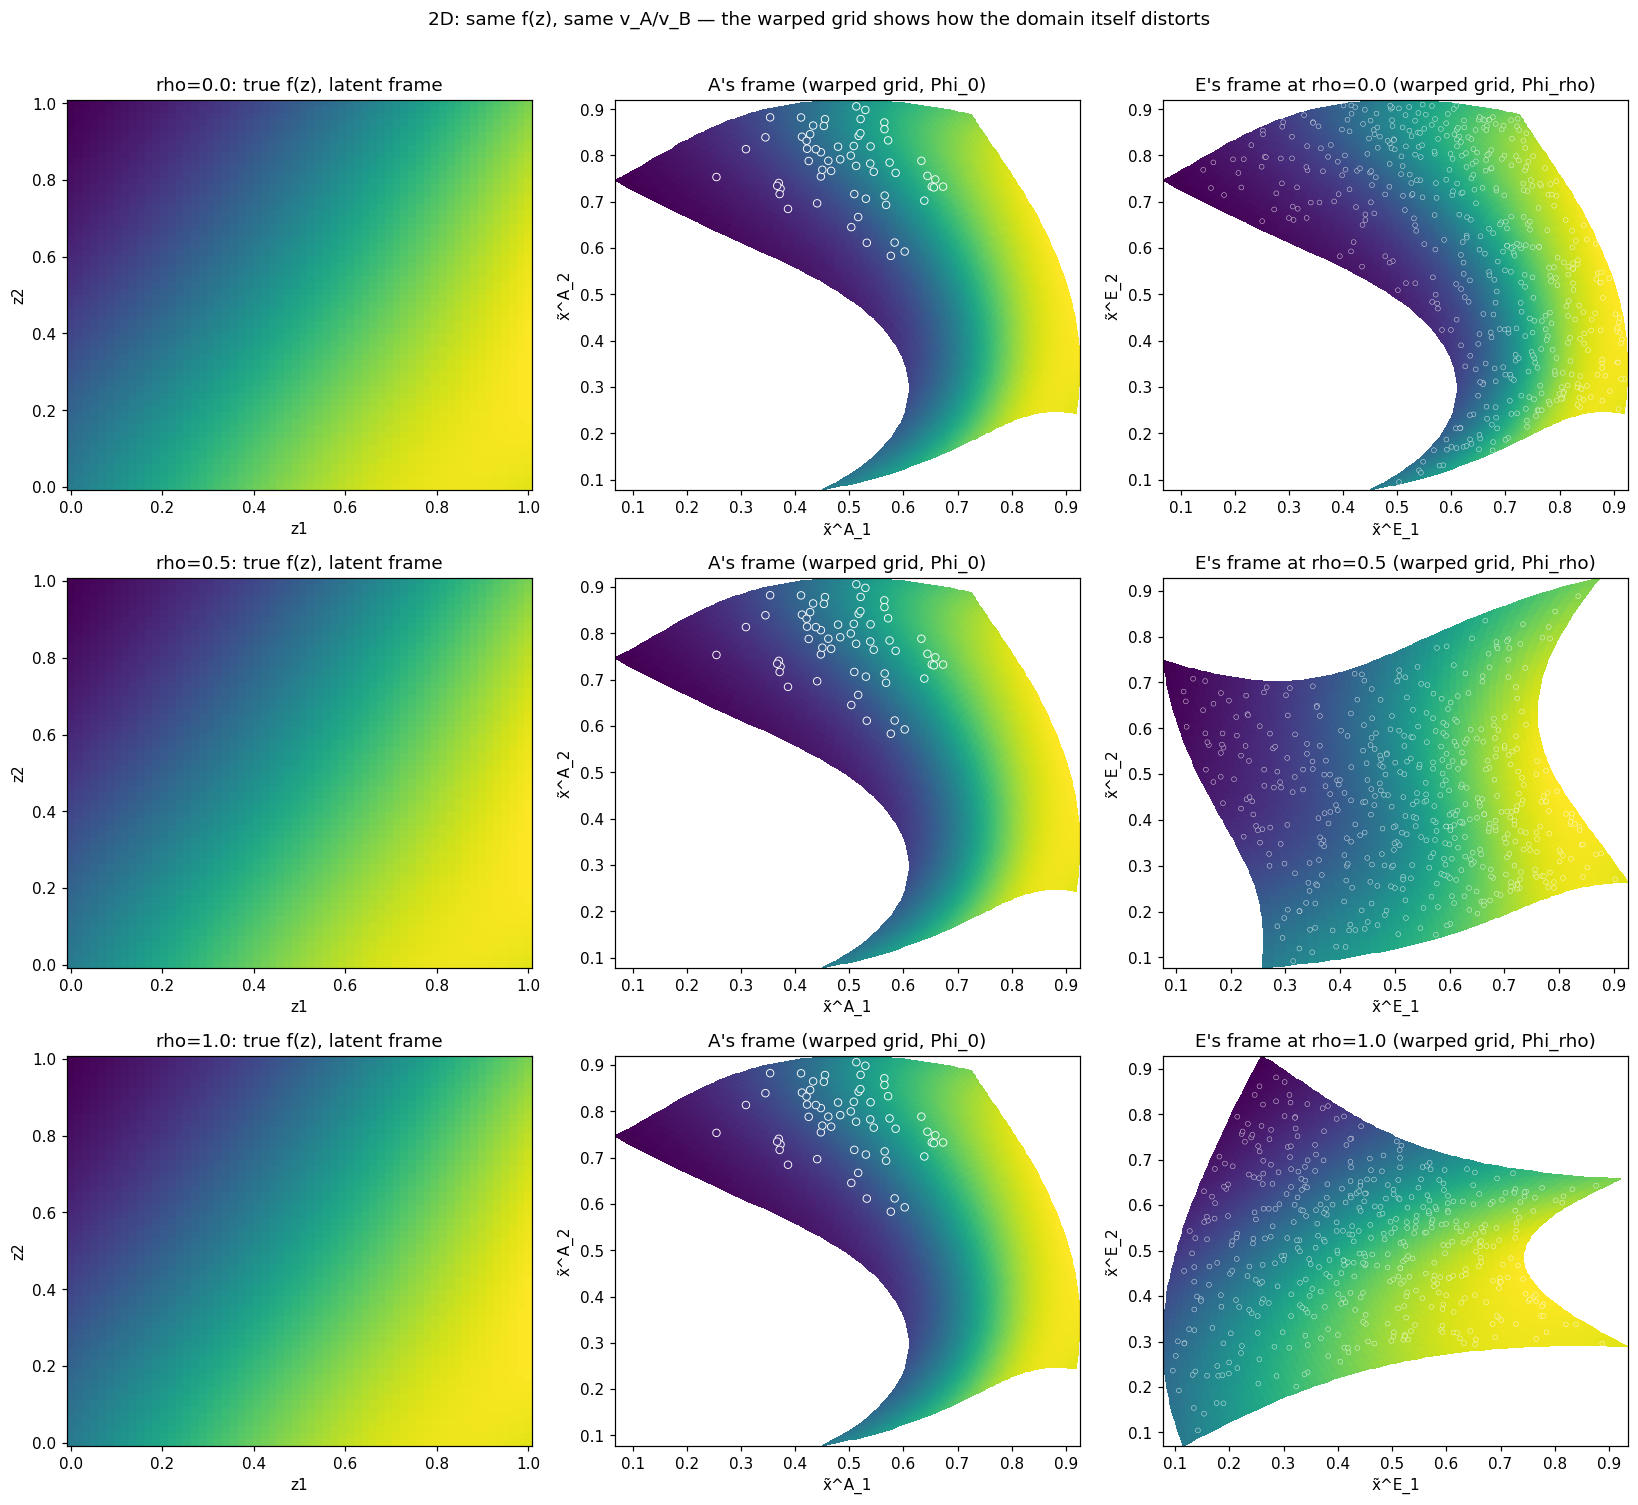

In [5]:
vmin, vmax = float(true_y_grid2.min()), float(true_y_grid2.max())
fig, axes = plt.subplots(len(RHOS), 3, figsize=(15, 4.5 * len(RHOS)), squeeze=False)

for row, rho in enumerate(RHOS):
    ax_z, ax_a, ax_e = axes[row]

    phi_rho2 = mix_velocity([v_a2, v_b2], [1.0 - rho, rho])
    box_e2 = declared_box(phi_rho2, D2)
    x_e_grid2 = normalize(flow_rk4(phi_rho2, z_grid2), box_e2)
    x_e_norm2 = normalize(flow_rk4(phi_rho2, z_b2), box_e2)
    y_e2 = f2.sample_y(rng2, z_b2)

    ax_z.pcolormesh(gz1, gz2, true_y_grid2, cmap="viridis", vmin=vmin, vmax=vmax, shading="auto")
    ax_z.set_title(f"rho={rho}: true f(z), latent frame")
    ax_z.set_xlabel("z1"); ax_z.set_ylabel("z2")

    # pcolormesh with 2D (curvilinear) X/Y is valid here because flow_rk4
    # warps the regular meshgrid point-by-point without reordering it --
    # the (i,j) grid topology (and hence quad connectivity) is preserved,
    # only the (x,y) positions move. That's exactly what a diffeomorphism
    # guarantees (no folds, no self-intersections).
    Xa1 = x_a_grid2[:, 0].reshape(GRID_N_2D, GRID_N_2D)
    Xa2 = x_a_grid2[:, 1].reshape(GRID_N_2D, GRID_N_2D)
    ax_a.pcolormesh(Xa1, Xa2, true_y_grid2, cmap="viridis", vmin=vmin, vmax=vmax, shading="auto")
    ax_a.scatter(x_a_norm2[:, 0], x_a_norm2[:, 1], c=y_a2, cmap="viridis", vmin=vmin, vmax=vmax,
                 s=24, edgecolor="white", linewidth=0.6, zorder=3)
    ax_a.set_title("A's frame (warped grid, Phi_0)")
    ax_a.set_xlabel("x̃^A_1"); ax_a.set_ylabel("x̃^A_2")

    Xe1 = x_e_grid2[:, 0].reshape(GRID_N_2D, GRID_N_2D)
    Xe2 = x_e_grid2[:, 1].reshape(GRID_N_2D, GRID_N_2D)
    ax_e.pcolormesh(Xe1, Xe2, true_y_grid2, cmap="viridis", vmin=vmin, vmax=vmax, shading="auto")
    # edgecolor="white" (not "none") -- otherwise same-colormap scatter dots
    # visually vanish into the heatmap they're drawn over.
    ax_e.scatter(x_e_norm2[:, 0], x_e_norm2[:, 1], c=y_e2, cmap="viridis", vmin=vmin, vmax=vmax,
                 s=10, edgecolor="white", linewidth=0.3, alpha=0.85, zorder=3)
    ax_e.set_title(f"E's frame at rho={rho} (warped grid, Phi_rho)")
    ax_e.set_xlabel("x̃^E_1"); ax_e.set_ylabel("x̃^E_2")

fig.suptitle("2D: same f(z), same v_A/v_B — the warped grid shows how the domain itself distorts", y=1.01)
fig.tight_layout()
plt.show()

**What to look for:** the grid lines (implicit in the pcolormesh quads) show the warp directly — a uniform grid bending/compressing/stretching, never crossing itself (diffeomorphism). At `rho=0` the E panel's grid should match A's panel exactly; as `rho` grows toward 1 the two grids diverge, and the color pattern (same underlying `f`) ends up mapped onto visibly different regions of `[0,1]^2`.